# Factor step scaling: is equal-$\rho$ the right A:B split?

Backs `docs/notes/factor_step_scaling.md`. Algorithm 1 gives both factor updates equal operator-norm budget ($\sigma_{\max}(\dot A)=\sigma_{\max}(\dot B)=\rho$, $\rho=\eta/(\sigma_{\max}(A)+\sigma_{\max}(B))$). Su/Muon-$\mu$P would split them asymmetrically. The $\mu$A frame (arXiv 2602.06204) says the right object is the bilinear feature increment $\Delta Z_B=\delta^1+\delta^2+\delta^3$ with $\delta^1=B\dot A$, $\delta^2=\dot B A$.

This notebook shows three measured facts:
1. **$A$ collapses** to a low-rank near-fixed projection (stable rank $48\to6$) — the $\mu$A frozen-$A$ picture under Init[A].
2. **$\sigma_{\max}(A)\approx\sigma_{\max}(B)$** $\Rightarrow$ $\|\delta^1\|\approx\|\delta^2\|$: equal-$\rho$ already balances the two factor contributions (the $\mu$A both-contribute ideal).
3. **$\sigma_{\max}(A)+\sigma_{\max}(B)$ is ~rank-invariant** $\Rightarrow$ $\rho\propto\eta$ at every rank: the operator-norm mechanism behind $\eta$-transfer across rank.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from lora_playground.snapshot_analysis import (
    SNAP_ROOTS, STEPS_BY_ROOT, RUN_E, RUN_F, RUN_A, RUN_B, load_snapshot,
)

# r=64 and r=256 runs at the 9000-step leaderboard horizon (k=1 best-eta), with
# fall-back to the k=3 snapshot runs if the k=1 ones are absent.
R64 = RUN_E if SNAP_ROOTS[RUN_E].exists() else RUN_A
R256 = RUN_F if SNAP_ROOTS[RUN_F].exists() else RUN_B
RUNS = {64: R64, 256: R256}
for r, key in RUNS.items():
    print(f'r={r}: {key}  steps={STEPS_BY_ROOT.get(key)}')

def factor_smax_stablerank(snap):
    """Per-pair sigma_max and stable rank of A and B from a snapshot."""
    ps = snap['pair_state']
    out = {'smA': [], 'smB': [], 'srA': [], 'srB': [], 'r': None}
    for k in list(ps):
        A = ps[k]['A'].float(); B = ps[k]['B'].float()
        out['r'] = A.shape[0]
        sA = torch.linalg.svdvals(A); sB = torch.linalg.svdvals(B)
        out['smA'].append(sA[0].item()); out['smB'].append(sB[0].item())
        out['srA'].append((sA.pow(2).sum() / sA[0].pow(2)).item())
        if sB[0] > 0:
            out['srB'].append((sB.pow(2).sum() / sB[0].pow(2)).item())
        else:
            out['srB'].append(np.nan)
    return {k: (np.array(v) if isinstance(v, list) else v) for k, v in out.items()}

r=64: ('3e-2', 64, 5, 'chord-tight-k1')  steps=[0, 500, 1000, 2000, 4000, 6000, 9000]
r=256: ('3e-2', 256, 5, 'chord-tight-k1')  steps=[0, 500, 1000, 2000, 4000, 6000, 9000]


## 1. $A$ collapses to a low-rank near-fixed projection

Stable rank $\|M\|_F^2/\sigma_{\max}^2$ of $A$ and $B$ vs step. $A$ inits near-isotropic ($\approx0.75\,r$, Marchenko–Pastur) and collapses to $\sim6$ effective directions; $B$ inits at $0$ and settles higher. Matches $\mu$A Init[A]: learning runs through $B$, $A$'s subspace is selected early.

In [2]:
# COMPUTE: stable-rank trajectories per run.
traj = {}
for r, key in RUNS.items():
    steps = STEPS_BY_ROOT.get(key, [])
    rows = []
    for st in steps:
        d = factor_smax_stablerank(load_snapshot(st, root=SNAP_ROOTS[key]))
        rows.append((st, np.nanmean(d['srA']), np.nanmean(d['srB']), d['r']))
    traj[r] = np.array([(s, a, b) for s, a, b, _ in rows])
    print(f'r={r}: ' + '  '.join(f'{int(s)}:A={a:.1f},B={b:.1f}' for s, a, b in traj[r]))

/tmp/ipykernel_3697381/1487964406.py:8: RuntimeWarning: Mean of empty slice
  rows.append((st, np.nanmean(d['srA']), np.nanmean(d['srB']), d['r']))


r=64: 0:A=48.0,B=nan  500:A=25.3,B=28.3  1000:A=21.8,B=28.3  2000:A=18.8,B=27.9  4000:A=16.1,B=27.4  6000:A=14.6,B=27.1  9000:A=13.2,B=26.6


r=256: 0:A=147.7,B=nan  500:A=60.6,B=52.1  1000:A=45.2,B=55.0  2000:A=32.3,B=57.9  4000:A=23.2,B=60.1  6000:A=19.3,B=60.5  9000:A=16.6,B=60.0


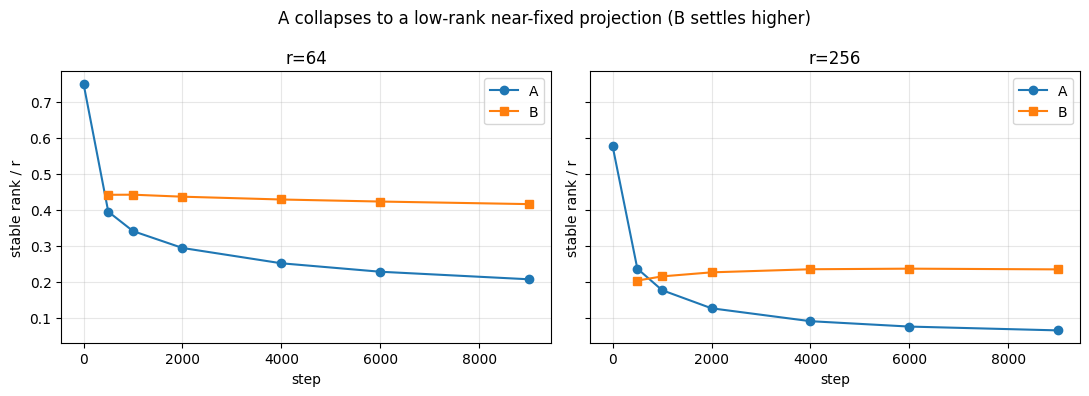

In [3]:
# PLOT: stable-rank trajectories (shared y-axis as fraction of r).
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (r, key) in zip(axes, RUNS.items()):
    t = traj[r]
    ax.plot(t[:, 0], t[:, 1] / r, 'o-', color='tab:blue', label='A')
    ax.plot(t[:, 0], t[:, 2] / r, 's-', color='tab:orange', label='B')
    ax.set_title(f'r={r}'); ax.set_xlabel('step')
    ax.set_ylabel('stable rank / r'); ax.grid(alpha=0.3); ax.legend()
fig.suptitle('A collapses to a low-rank near-fixed projection (B settles higher)')
fig.tight_layout(); plt.show()

## 2 & 3. $\sigma_{\max}$ balance and rank-invariance

At the final step (9000): per-pair $\sigma_{\max}(A)$ vs $\sigma_{\max}(B)$ (should cluster on the diagonal $\Rightarrow$ $\|\delta^1\|\approx\|\delta^2\|$), and the mean sum $\sigma_{\max}(A)+\sigma_{\max}(B)$ across rank (should be ~flat $\Rightarrow$ $\rho\propto\eta$ at every rank).

In [4]:
# COMPUTE: per-pair sigma_max at the final step for each rank.
final = {}
for r, key in RUNS.items():
    st = STEPS_BY_ROOT[key][-1]
    final[r] = factor_smax_stablerank(load_snapshot(st, root=SNAP_ROOTS[key]))
    smA, smB = final[r]['smA'], final[r]['smB']
    print(f'r={r} step{st}: sigma_max(A)={smA.mean():.3f}  sigma_max(B)={smB.mean():.3f}  '
          f'sum={smA.mean()+smB.mean():.3f}  ratio B/A={smB.mean()/smA.mean():.3f}')

r=64 step9000: sigma_max(A)=2.737  sigma_max(B)=2.706  sum=5.444  ratio B/A=0.989


r=256 step9000: sigma_max(A)=3.216  sigma_max(B)=2.432  sum=5.648  ratio B/A=0.756


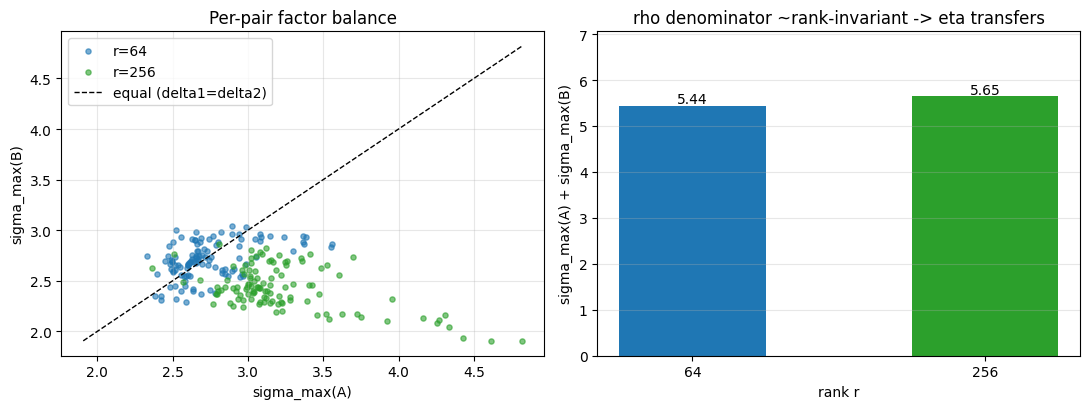

In [5]:
# PLOT: (a) sigma_max balance scatter, (b) sum-vs-rank invariance bar.
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {64: 'tab:blue', 256: 'tab:green'}
lo, hi = np.inf, -np.inf
for r in RUNS:
    smA, smB = final[r]['smA'], final[r]['smB']
    ax0.scatter(smA, smB, s=14, alpha=0.6, color=colors[r], label=f'r={r}')
    lo = min(lo, smA.min(), smB.min()); hi = max(hi, smA.max(), smB.max())
ax0.plot([lo, hi], [lo, hi], 'k--', lw=1, label='equal (delta1=delta2)')
ax0.set_xlabel('sigma_max(A)'); ax0.set_ylabel('sigma_max(B)')
ax0.set_title('Per-pair factor balance'); ax0.legend(); ax0.grid(alpha=0.3)

ranks = list(RUNS)
sums = [final[r]['smA'].mean() + final[r]['smB'].mean() for r in ranks]
ax1.bar([str(r) for r in ranks], sums, color=[colors[r] for r in ranks], width=0.5)
for x, s in enumerate(sums):
    ax1.text(x, s + 0.05, f'{s:.2f}', ha='center')
ax1.set_xlabel('rank r'); ax1.set_ylabel('sigma_max(A) + sigma_max(B)')
ax1.set_title('rho denominator ~rank-invariant -> eta transfers')
ax1.set_ylim(0, max(sums) * 1.25); ax1.grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()